# Correlation And Bivariate Visualization Analysis Results (Attrition vs. Key Categorical Features)

In [1]:
# Upload dataset and read it into a pandas DataFrame
%pip install pandas
import pandas as pd

path = r"C:\Users\ramir\OneDrive\TMU Capstone\HR-Employee-Attrition-Dataset.csv"
df = pd.read_csv(path)
df.head()

Note: you may need to restart the kernel to use updated packages.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Correlation & Feature Selection Insights
Based on the correlation matrix below, several columns exhibit high multicollinearity or redundant information. To improve model performance and interpretability, the following adjustments are recommended:

**Multicollinearity Management**
* Tenure-Related Features: YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager, and YearsSinceLastPromotion are strongly correlated as they all measure time-based seniority.
* Decision: We will retain YearsAtCompany and YearsSinceLastPromotion as they show the strongest individual relationships with attrition in this dataset.

**Redundancy & Hierarchy**
* Nested Categories: JobRole is a more granular version of Department (e.g., Sales Executives and Sales Reps are both in the Sales Department).
* Decision: We keep JobRole to capture specific role-based variances and remove Department to reduce dimensionality without losing critical detail.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


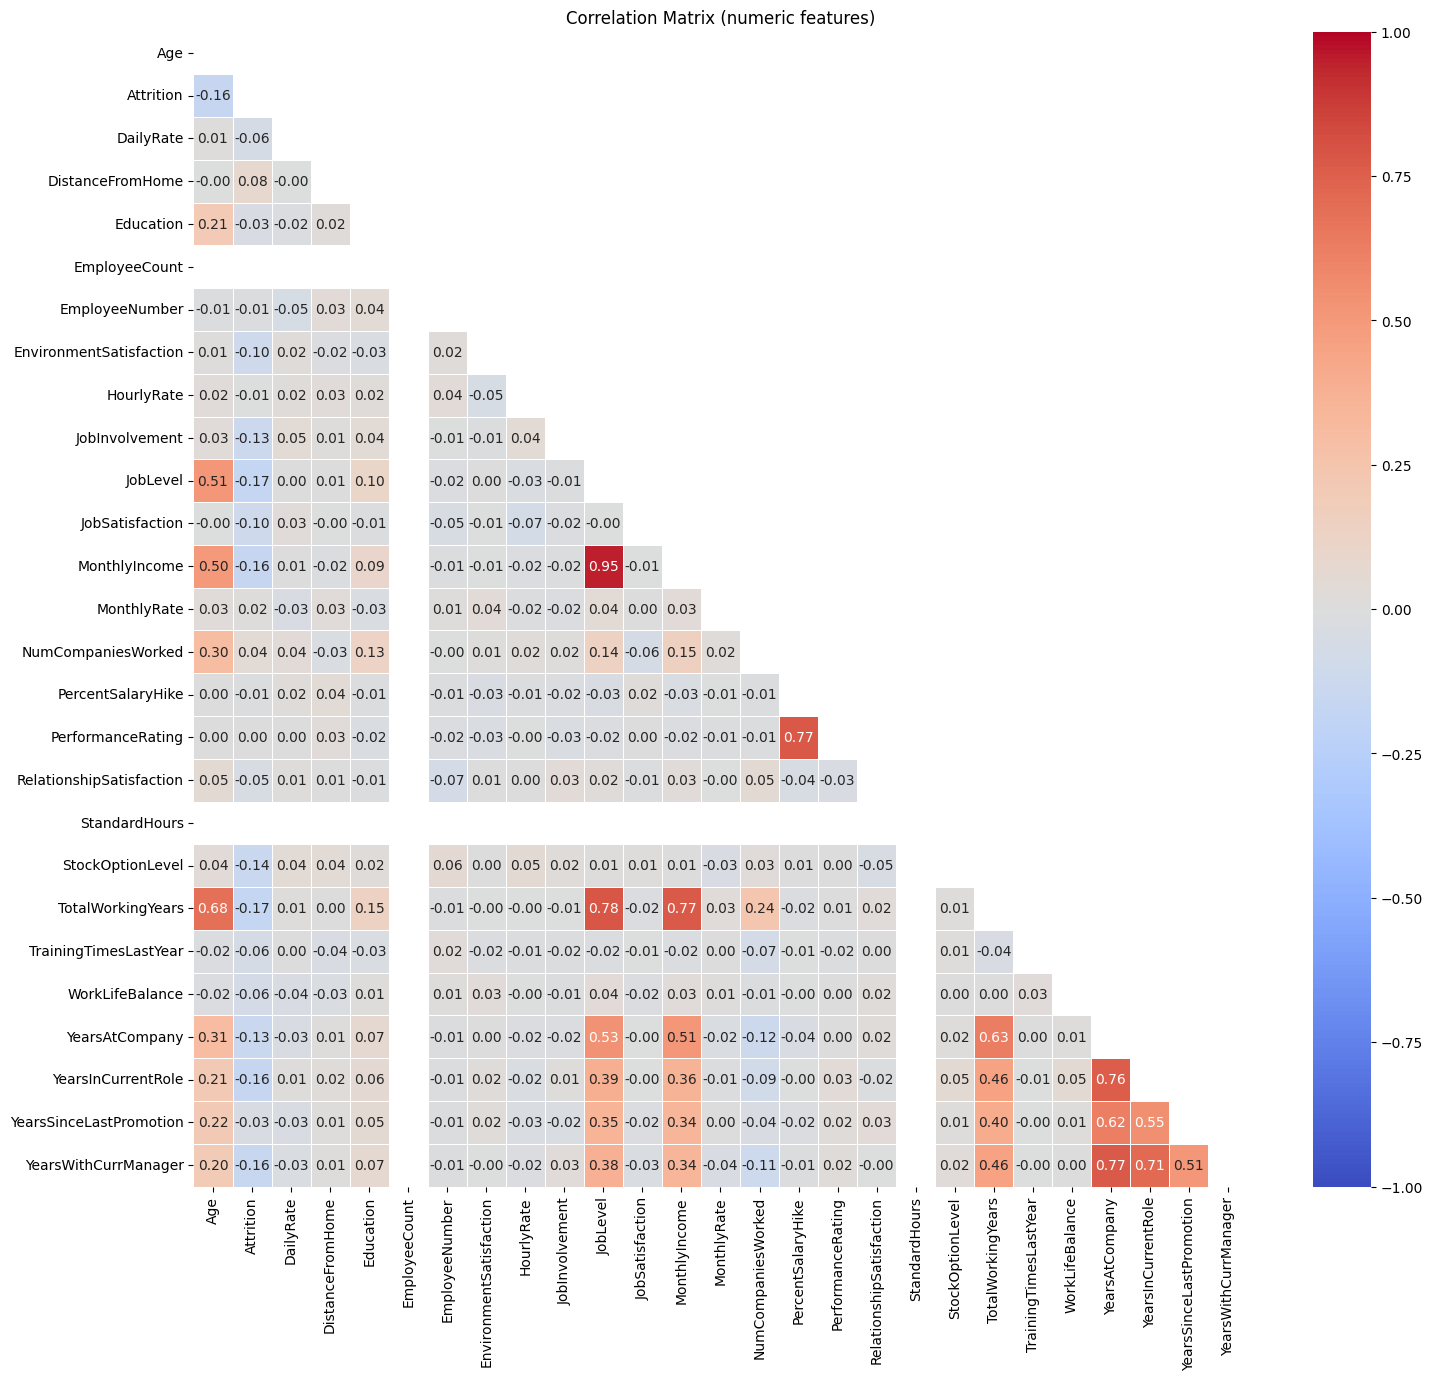

In [3]:
#Correlation Matrix for numeric features
%pip install seaborn
%pip install numpy
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


# convert Attrition to numeric and compute correlations for numeric columns
df_corr = df.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})
num_cols = df_corr.select_dtypes(include='number').columns
corr = df_corr[num_cols].corr()

# plot heatmap (mask upper triangle)
plt.figure(figsize=(17, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix (numeric features)")
plt.show()

## Bivariate Analysis: Key Findings (Attrition vs. Features)

**Job Role & Department**
* Highest Risk: Sales Representatives (~40% attrition), followed by Laboratory Technicians (~24%) and HR (~23%). These roles typically involve lower pay and higher routine tasks.
* Stability: Research Directors (~3%) and Managers (~5%) are the most stable roles.
* The "Revolving Door" in Sales: While R&D has the highest raw volume of departures (due to its size), the Sales department has a significantly higher percentage loss. This points to a high-pressure, target-driven culture where skills are highly marketable.

**Education & Field**
* Technical vs. Medical: Employees with Technical Degrees and Marketing backgrounds show higher percentage-based attrition.
* Degree Level: Employees with a Bachelor’s (Level 3) leave most often, whereas those with a Doctorate (Level 5) have the highest retention, likely due to seniority and compensation.

**The Burnout Factors: Travel & Overtime**
* Business Travel: Frequent Travelers have a 25% attrition rate compared to only 8% for non-travelers. High travel is a clear burnout catalyst.
* Overtime: This is the strongest predictor. Employees working overtime have a 30% attrition rate, vs. 10% for those who don't. This is a critical "red flag" for HR intervention.

**Demographics & Lifestyle**
* Age: The 18-25 age bracket has the highest attrition (36%). Stability increases significantly after age 40.
* Marital Status: Single employees (~25% attrition) are more mobile than Married or Divorced employees, who often prioritize stability due to family constraints.
* Satisfaction & Balance: Attrition drops steadily as Work-Life Balance and Environment Satisfaction improve, highlighting the value of workplace culture and flexible arrangements.

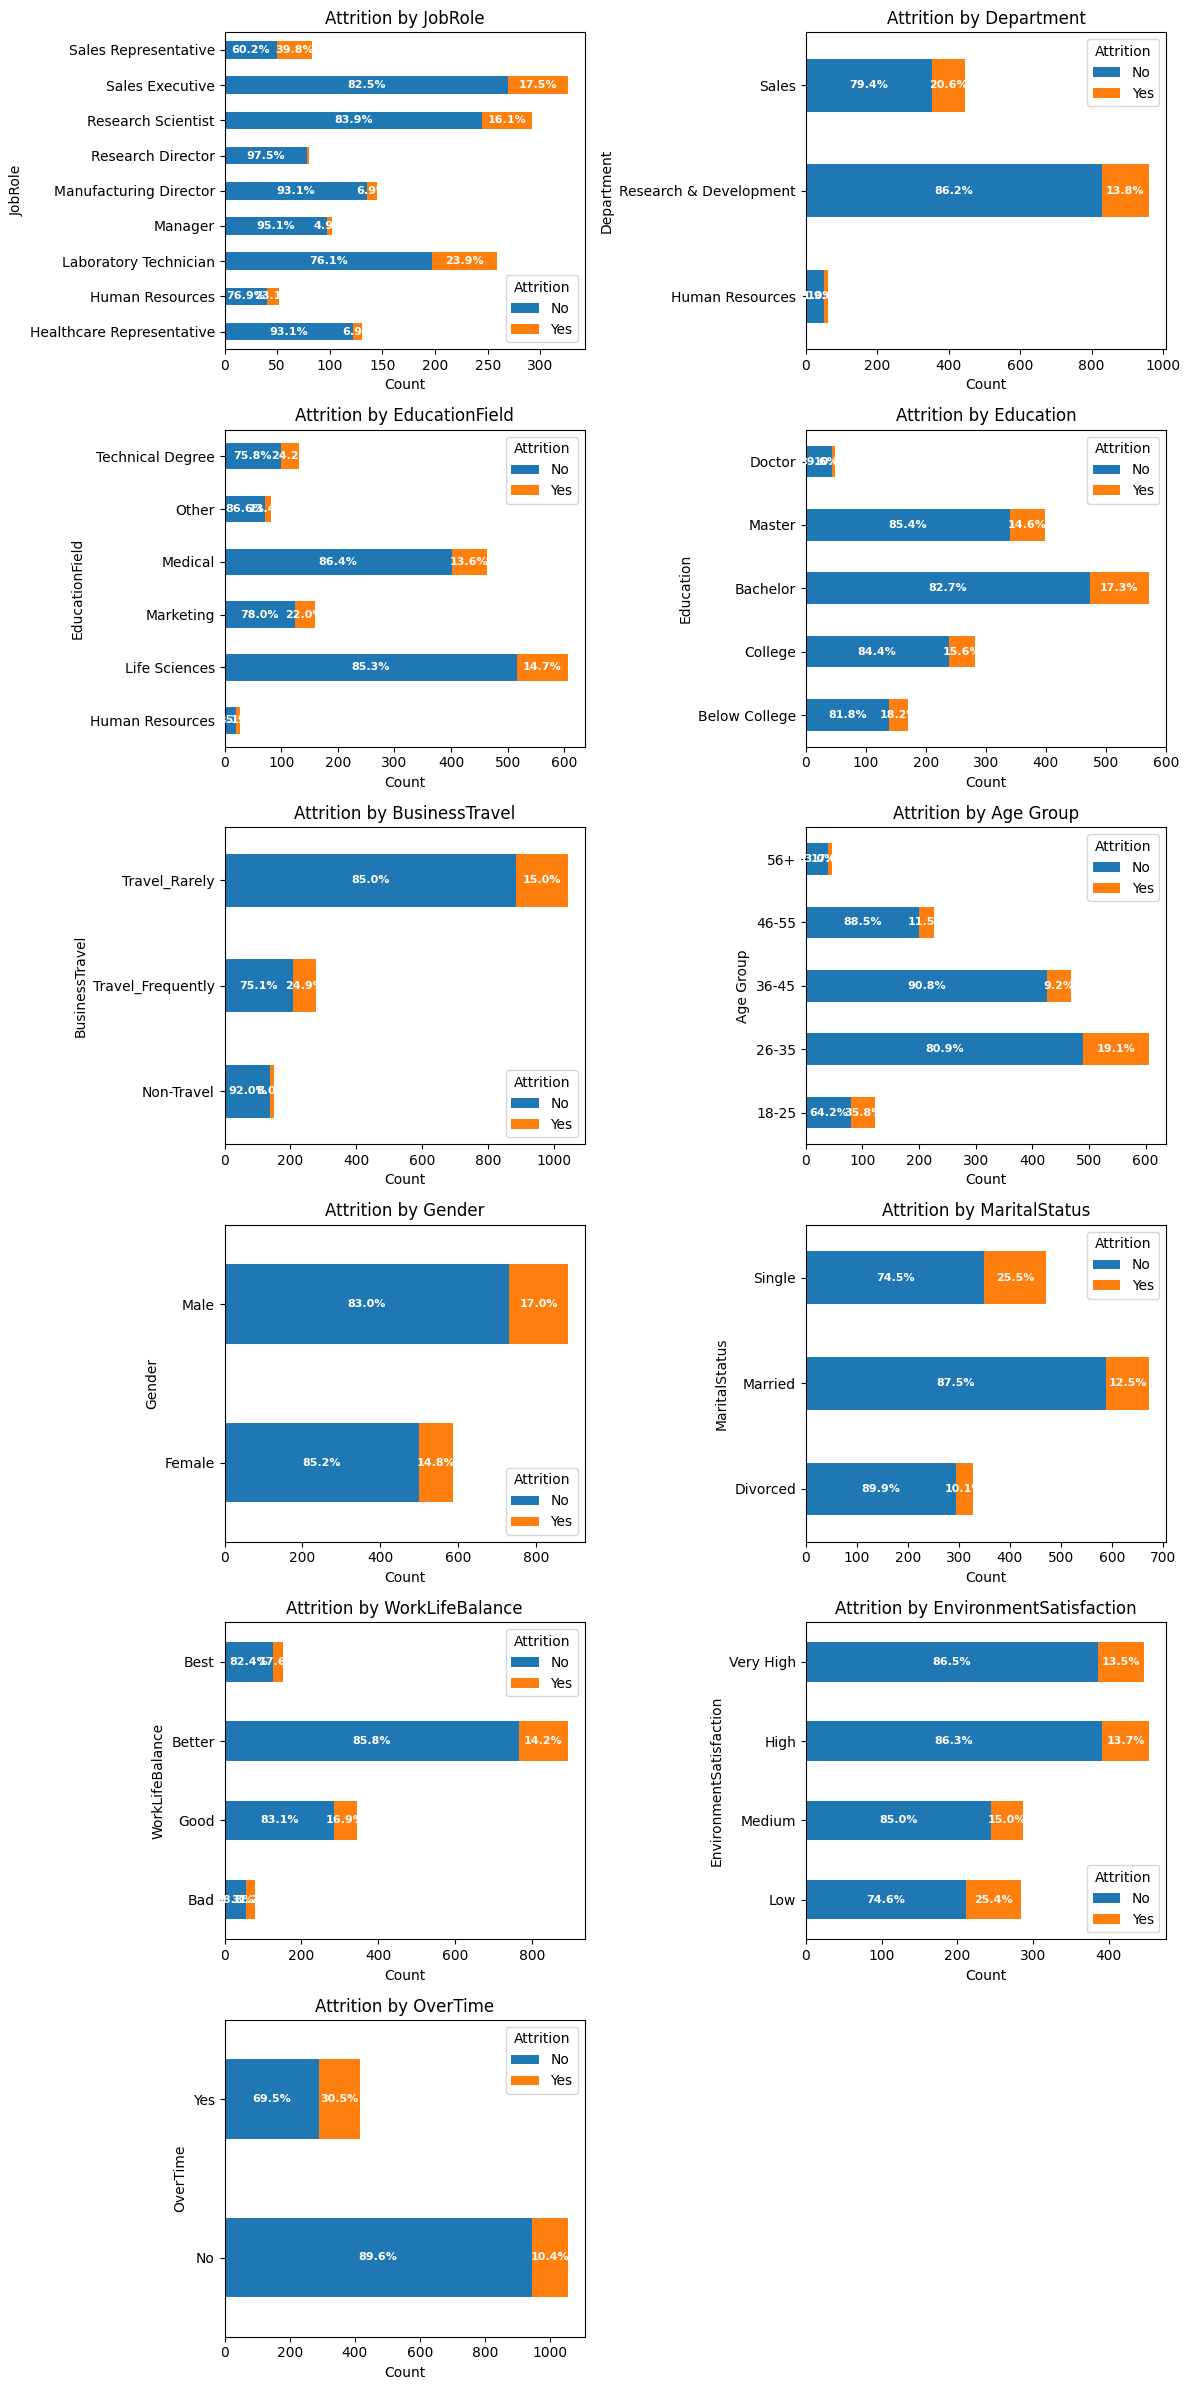

In [10]:
# Horizontal stacked bar charts: 2 per row for multiple categorical features
fig, axes = plt.subplots(6, 2, figsize=(12, 24))
axes = axes.flatten()

# Define the features and their labels (if needed)
features = [
    ('JobRole', None),
    ('Department', None),
    ('EducationField', None),
    ('Education', {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}),
    ('BusinessTravel', None),
    ('Age', None),  # Will bin Age into groups
    ('Gender', None),
    ('MaritalStatus', None),
    ('WorkLifeBalance', {1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'}),
    ('EnvironmentSatisfaction', {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}),
    ('OverTime', None)
]

for idx, (feature, label_map) in enumerate(features):
    ax = axes[idx]
    
    # Special handling for Age - create age groups
    if feature == 'Age':
        df_plot = df.copy()
        df_plot['AgeGroup'] = pd.cut(df_plot['Age'], bins=[0, 25, 35, 45, 55, 100], 
                                      labels=['18-25', '26-35', '36-45', '46-55', '56+'])
        ct = pd.crosstab(df_plot['AgeGroup'], df_plot['Attrition'])
        title = 'Attrition by Age Group'
        ylabel = 'Age Group'
    else:
        ct = pd.crosstab(df[feature], df['Attrition'])
        title = f'Attrition by {feature}'
        ylabel = feature
    
    # Apply label mapping if provided
    if label_map:
        ct.index = ct.index.map(label_map)
    
    # Create horizontal stacked bar chart
    ct.plot(kind='barh', stacked=True, ax=ax, color=['tab:blue', 'tab:orange'])
    
    # Add percentage labels to each bar segment
    totals = ct.sum(axis=1)
    for i, (row_name, row_data) in enumerate(ct.iterrows()):
        total = totals.iloc[i]
        x_offset = 0
        for col_name, value in row_data.items():
            if total > 0:
                percent = (value / total) * 100
                # Only show label if percentage is significant
                if percent > 3:
                    ax.text(x_offset + value/2, i, 
                           f'{percent:.1f}%',
                           ha='center', va='center', fontsize=8, color='white', weight='bold')
            x_offset += value
    
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_ylabel(ylabel)
    ax.legend(title='Attrition', loc='best')

# Hide the last empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Executive Summary: The "High-Risk" Profile

Based on all the bivariate relationships analyzed, an employee is statistically most likely to leave if they fit the following criteria:
* Role: Sales Representative or Laboratory Technician.
* Education: Bachelor educated or below.
* Work Habit: Frequently works Overtime.
* Demographics: Under age 25, Single, and travels frequently for business.
* Top Predictors of Attrition: Overtime, Monthly Income, Age, and Job Level.
